# Exploratory Data Analysis: Insurance Enrollment Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
df = pd.read_csv('../data/employee_data.csv')
df.head(10)

,employee_id,age,gender,marital_status,salary,employment_type,region,has_dependents,tenure_years,enrolled
0,10001,60,Female,Single,55122.97,Part-time,West,No,1.5,0
1,10002,50,Female,Single,89549.66,Full-time,West,Yes,12.8,1
2,10003,36,Male,Divorced,74145.66,Part-time,Midwest,No,3.8,0
3,10004,64,Female,Married,53877.83,Full-time,Northeast,No,3.3,0
4,10005,29,Male,Single,63404.63,Contract,Midwest,Yes,10.0,0
5,10006,42,Male,Married,66274.58,Contract,West,Yes,1.0,1
6,10007,60,Male,Divorced,63415.31,Full-time,South,Yes,3.3,1
7,10008,40,Male,Married,60616.13,Full-time,West,No,3.1,1
8,10009,44,Female,Single,83459.03,Full-time,South,Yes,0.3,1
9,10010,32,Male,Divorced,72926.06,Part-time,South,No,10.8,0


## 1. Data Overview

In [3]:
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumn types:\n{df.dtypes}")

Dataset shape: 10000 rows, 10 columns

Column types:
employee_id          int64
age                  int64
gender              object
marital_status      object
salary             float64
employment_type     object
region              object
has_dependents      object
tenure_years       float64
enrolled             int64
dtype: object


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   employee_id      10000 non-null  int64  
 1   age              10000 non-null  int64  
 2   gender           10000 non-null  object 
 3   marital_status   10000 non-null  object 
 4   salary           10000 non-null  float64
 5   employment_type  10000 non-null  object 
 6   region           10000 non-null  object 
 7   has_dependents   10000 non-null  object 
 8   tenure_years     10000 non-null  float64
 9   enrolled         10000 non-null  int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 781.4+ KB


There are no null values in the dataset

In [5]:
df.describe()

,employee_id,age,salary,tenure_years,enrolled
count,10000.00000,10000.0000,10000.000000,10000.000000,10000.000000
mean,15000.50000,43.0020,65032.967907,3.967720,0.617400
std,2886.89568,12.2858,14923.958446,3.895488,0.486046
min,10001.00000,22.0000,2207.790000,0.000000,0.000000
25%,12500.75000,33.0000,54714.342500,1.200000,0.000000
50%,15000.50000,43.0000,65056.050000,2.800000,1.000000
75%,17500.25000,54.0000,75053.687500,5.600000,1.000000
max,20000.00000,64.0000,120312.000000,36.000000,1.000000


## 2. Missing Values

In [26]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df[missing_df['missing_count'] > 0] if missing.sum() > 0 else print("No missing values found!")

No missing values found!


## 3. Target Variable: Class Balance

In [30]:
enrolled_counts = df['enrolled'].value_counts()
enrolled_pct = df['enrolled'].value_counts(normalize=True) * 100

print("Enrollment distribution:")
print(f"  Not Enrolled (0): {enrolled_counts[0]:,} ({enrolled_pct[0]:.1f}%)")
print(f"  Enrolled (1):     {enrolled_counts[1]:,} ({enrolled_pct[1]:.1f}%)")
print(f"\nImbalance ratio: {enrolled_counts[0]/enrolled_counts[1]:.2f}:1")

Enrollment distribution:
  Not Enrolled (0): 3,826 (38.3%)
  Enrolled (1):     6,174 (61.7%)

Imbalance ratio: 0.62:1


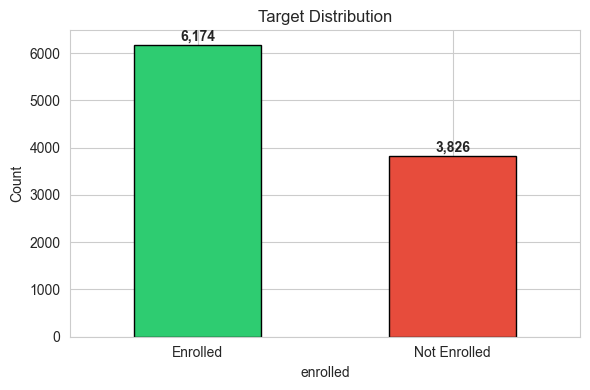

In [32]:
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#2ecc71', '#e74c3c']
df['enrolled'].value_counts().plot(kind='bar', color=colors, edgecolor='black', ax=ax)
ax.set_xticklabels(['Enrolled', 'Not Enrolled'], rotation=0)
ax.set_ylabel('Count')
ax.set_title('Target Distribution')
for i, v in enumerate(enrolled_counts):
    ax.text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Numerical Features Distribution

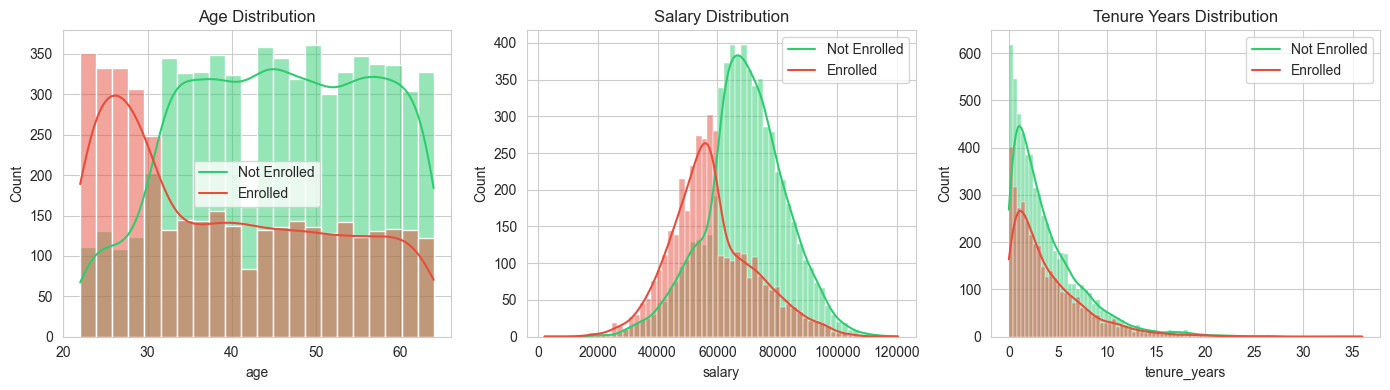

In [ ]:
numerical_cols = ['age', 'salary', 'tenure_years']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, col in enumerate(numerical_cols):
    sns.histplot(data=df, x=col, hue='enrolled', kde=True, ax=axes[i], 
                 palette={0: '#e74c3c', 1: '#2ecc71'})
    axes[i].set_title(f'{col.replace("_", " ").title()} Distribution')
    axes[i].legend(title='', labels=['Enrolled', 'Not Enrolled'])

plt.tight_layout()
plt.show()

/var/folders/w_/gx_mdgh125lfzwmrfrb9cf280000gn/T/ipykernel_62692/3976305011.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='enrolled', y=col, ax=axes[i],
/var/folders/w_/gx_mdgh125lfzwmrfrb9cf280000gn/T/ipykernel_62692/3976305011.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Not Enrolled', 'Enrolled'])
/var/folders/w_/gx_mdgh125lfzwmrfrb9cf280000gn/T/ipykernel_62692/3976305011.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='enrolled', y=col, ax=axes[i],
/var/folders/w_/gx_mdgh125lfzwmrfrb9cf280000gn/T/ipykernel_62692/3976305011.py:6: UserWarnin

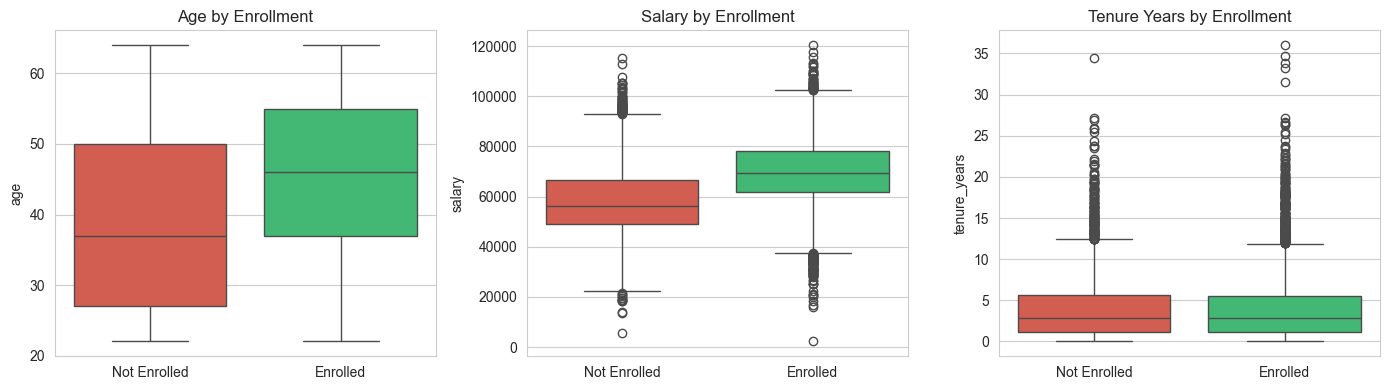

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x='enrolled', y=col, ax=axes[i], 
                palette=['#e74c3c', '#2ecc71'], order=[0, 1])
    axes[i].set_xticklabels(['Not Enrolled', 'Enrolled'])
    axes[i].set_xlabel('')
    axes[i].set_title(f'{col.replace("_", " ").title()} by Enrollment')

plt.tight_layout()
plt.show()

In [11]:
print("Numerical features by enrollment status:\n")
df.groupby('enrolled')[numerical_cols].agg(['mean', 'median', 'std']).round(2)

Numerical features by enrollment status:



age                  salary                     tenure_years  \
           mean median    std      mean    median       std         mean   
enrolled                                                                   
0         38.81   37.0  12.91  58087.02  56407.88  14350.89         4.00   
1         45.60   46.0  11.11  69337.34  69396.62  13591.27         3.94   

                       
         median   std  
enrolled               
0           2.8  3.90  
1           2.8  3.89

## 5. Categorical Features Distribution

In [12]:
categorical_cols = ['gender', 'marital_status', 'employment_type', 'region', 'has_dependents']

for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

gender: ['Female' 'Male' 'Other']
marital_status: ['Single' 'Divorced' 'Married' 'Widowed']
employment_type: ['Part-time' 'Full-time' 'Contract']
region: ['West' 'Midwest' 'Northeast' 'South']
has_dependents: ['No' 'Yes']


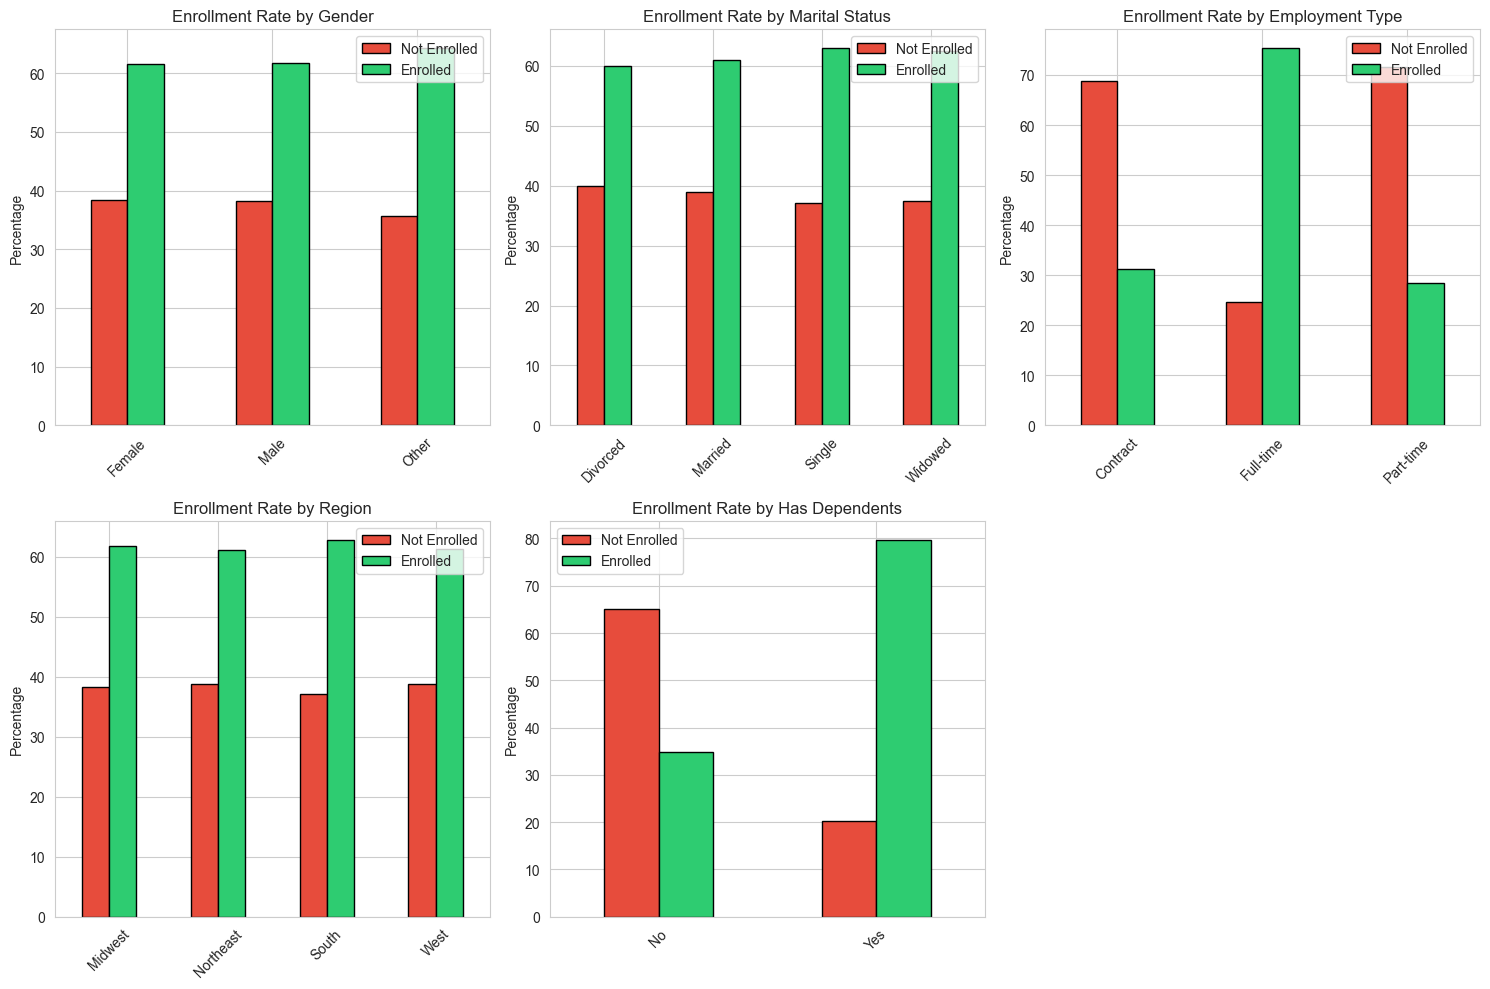

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df[col], df['enrolled'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#e74c3c', '#2ecc71'], edgecolor='black')
    axes[i].set_title(f'Enrollment Rate by {col.replace("_", " ").title()}')
    axes[i].set_ylabel('Percentage')
    axes[i].set_xlabel('')
    axes[i].legend(['Not Enrolled', 'Enrolled'])
    axes[i].tick_params(axis='x', rotation=45)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
print("Enrollment breakdown by category:\n")
for col in categorical_cols:
    stats = df.groupby(col)['enrolled'].agg(['sum', 'count'])
    stats.columns = ['enrolled', 'total']
    stats['not_enrolled'] = stats['total'] - stats['enrolled']
    stats['enroll_rate_%'] = (stats['enrolled'] / stats['total'] * 100).round(1)
    stats = stats[['total', 'enrolled', 'not_enrolled', 'enroll_rate_%']]
    print(f"\n{col.upper()}")
    print(stats.to_string())

## 6. Correlation Analysis

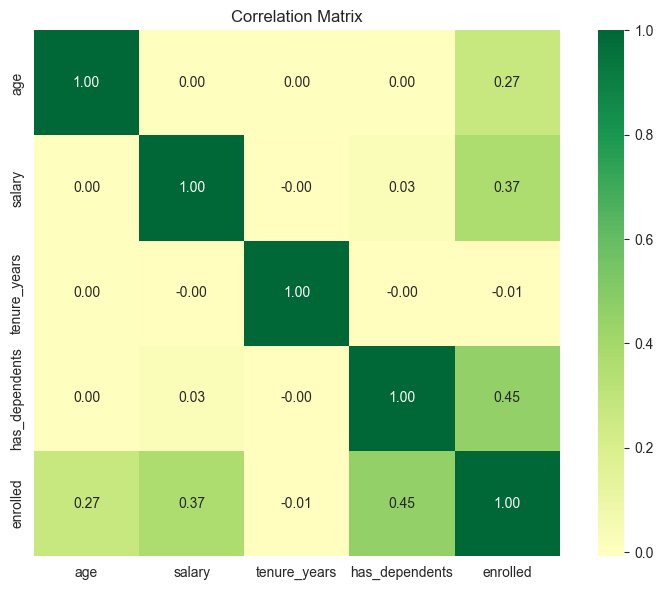

In [15]:
df_encoded = df.copy()
df_encoded['has_dependents'] = (df_encoded['has_dependents'] == 'Yes').astype(int)

corr_cols = numerical_cols + ['has_dependents', 'enrolled']
correlation_matrix = df_encoded[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', center=0, fmt='.2f', square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [16]:
print("Correlation with target (enrolled):\n")
target_corr = correlation_matrix['enrolled'].drop('enrolled').sort_values(key=abs, ascending=False)
for feat, corr in target_corr.items():
    direction = "positive" if corr > 0 else "negative"
    print(f"  {feat:20} {corr:+.3f}  ({direction})")

Correlation with target (enrolled):

  has_dependents       +0.453  (positive)
  salary               +0.366  (positive)
  age                  +0.269  (positive)
  tenure_years         -0.007  (negative)


## 7. Pattern Analysis: Dependents Impact

In [45]:
stats = df.groupby('has_dependents')['enrolled'].agg(['sum', 'count'])
stats.columns = ['enrolled', 'total']
stats['not_enrolled'] = stats['total'] - stats['enrolled']
stats['enroll_rate_%'] = (stats['enrolled'] / stats['total'] * 100).round(1)

print("Impact of dependents on enrollment:\n")
print(stats[['total', 'enrolled', 'not_enrolled', 'enroll_rate_%']].to_string())

rate_yes = stats.loc['Yes', 'enroll_rate_%']
rate_no = stats.loc['No', 'enroll_rate_%']
abs_diff = rate_yes - rate_no
rel_diff = (rate_yes - rate_no) / rate_no * 100

print(f"\nWith dependents: {rate_yes}% enroll")
print(f"Without dependents: {rate_no}% enroll")
print(f"Absolute difference: {abs_diff:.1f} percentage points")
print(f"Relative difference: {rel_diff:.0f}% higher enrollment rate")

Impact of dependents on enrollment:

                total  enrolled  not_enrolled  enroll_rate_%
has_dependents                                              
No               4007      1395          2612           34.8
Yes              5993      4779          1214           79.7

With dependents: 79.7% enroll
Without dependents: 34.8% enroll
Absolute difference: 44.9 percentage points
Relative difference: 129% higher enrollment rate


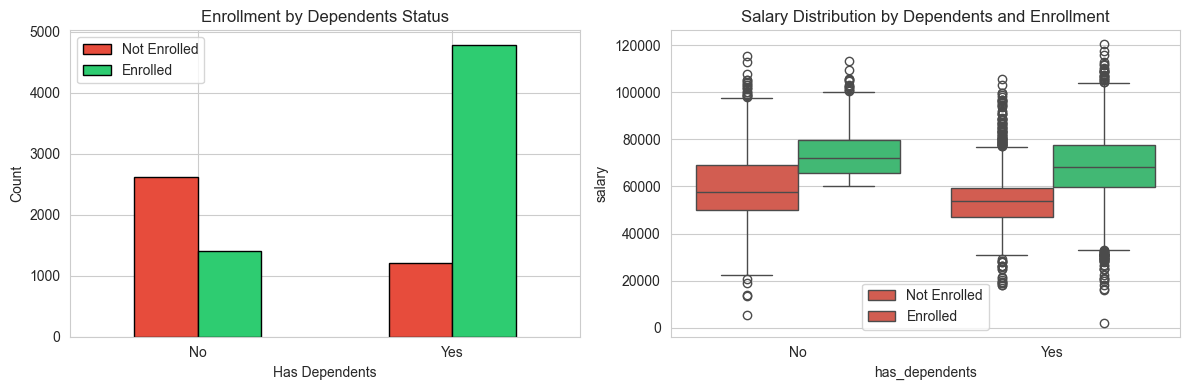

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Dependents vs Enrollment
ct = pd.crosstab(df['has_dependents'], df['enrolled'])
ct.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Enrollment by Dependents Status')
axes[0].set_xlabel('Has Dependents')
axes[0].set_ylabel('Count')
axes[0].legend(['Not Enrolled', 'Enrolled'])
axes[0].tick_params(axis='x', rotation=0)

# Salary vs Dependents interaction
sns.boxplot(data=df, x='has_dependents', y='salary', hue='enrolled', ax=axes[1], palette=['#e74c3c', '#2ecc71'])
axes[1].set_title('Salary Distribution by Dependents and Enrollment')
axes[1].legend(['Not Enrolled', 'Enrolled'])

plt.tight_layout()
plt.show()

## 8. Multi-Feature Patterns

In [19]:
# High-value segments: who enrolls most?
segment_analysis = df.groupby(['has_dependents', 'employment_type']).agg(
    enrollment_rate=('enrolled', 'mean'),
    count=('enrolled', 'count'),
    avg_salary=('salary', 'mean')
).round(3)

segment_analysis['enrollment_rate'] = (segment_analysis['enrollment_rate'] * 100).round(1)
segment_analysis = segment_analysis.sort_values('enrollment_rate', ascending=False)

print("Enrollment rates by segment (Dependents + Employment Type):\n")
print(segment_analysis)

Enrollment rates by segment (Dependents + Employment Type):

                                enrollment_rate  count  avg_salary
has_dependents employment_type                                    
Yes            Full-time                   92.8   4213   65462.179
               Contract                    49.9    617   65306.854
No             Full-time                   49.3   2828   64579.536
Yes            Part-time                   48.3   1163   64981.459
No             Contract                     0.0    369   64629.591
               Part-time                    0.0    810   64432.726


In [20]:
# Age groups analysis
df['age_group'] = pd.cut(df['age'], bins=[18, 30, 40, 50, 65], labels=['18-30', '31-40', '41-50', '51-65'])

age_enrollment = df.groupby('age_group')['enrolled'].agg(['mean', 'count'])
age_enrollment.columns = ['enrollment_rate', 'count']
age_enrollment['enrollment_rate'] = (age_enrollment['enrollment_rate'] * 100).round(1)

print("Enrollment by age group:\n")
print(age_enrollment)

Enrollment by age group:

           enrollment_rate  count
age_group                        
18-30                 26.4   2027
31-40                 69.6   2377
41-50                 70.9   2405
51-65                 71.5   3191


/var/folders/w_/gx_mdgh125lfzwmrfrb9cf280000gn/T/ipykernel_62692/340100358.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_enrollment = df.groupby('age_group')['enrolled'].agg(['mean', 'count'])


In [21]:
# Salary bands
df['salary_band'] = pd.cut(df['salary'], bins=[0, 40000, 60000, 80000, 150000], 
                           labels=['<40k', '40-60k', '60-80k', '>80k'])

salary_enrollment = df.groupby('salary_band')['enrolled'].agg(['mean', 'count'])
salary_enrollment.columns = ['enrollment_rate', 'count']
salary_enrollment['enrollment_rate'] = (salary_enrollment['enrollment_rate'] * 100).round(1)

print("Enrollment by salary band:\n")
print(salary_enrollment)

Enrollment by salary band:

             enrollment_rate  count
salary_band                        
<40k                    31.9    442
40-60k                  33.1   3291
60-80k                  78.7   4681
>80k                    79.3   1586


/var/folders/w_/gx_mdgh125lfzwmrfrb9cf280000gn/T/ipykernel_62692/3707055830.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  salary_enrollment = df.groupby('salary_band')['enrolled'].agg(['mean', 'count'])


## 9. Key Findings Summary

In [22]:
print("="*60)
print("EDA SUMMARY")
print("="*60)

print(f"\n1. DATASET: {df.shape[0]:,} employees, {df.shape[1]} features")
print(f"   Missing values: {df.isnull().sum().sum()}")

print(f"\n2. CLASS BALANCE:")
print(f"   Enrolled: {enrolled_pct[1]:.1f}% | Not Enrolled: {enrolled_pct[0]:.1f}%")
balance_status = "Balanced" if 0.4 < enrolled_pct[1]/100 < 0.6 else "Imbalanced"
print(f"   Status: {balance_status}")

print(f"\n3. TOP PREDICTIVE FEATURES (by correlation):")
for feat, corr in target_corr.head(3).items():
    print(f"   - {feat}: {corr:+.3f}")

print(f"\n4. KEY INSIGHTS:")
print(f"   - Employees with dependents: {rate_diff:.1f}% higher enrollment")
print(f"   - Higher salary correlates with higher enrollment")
print(f"   - Full-time employees show different patterns than Part-time/Contract")

EDA SUMMARY

1. DATASET: 10,000 employees, 12 features
   Missing values: 0

2. CLASS BALANCE:
   Enrolled: 61.7% | Not Enrolled: 38.3%
   Status: Imbalanced

3. TOP PREDICTIVE FEATURES (by correlation):
   - has_dependents: +0.453
   - salary: +0.366
   - age: +0.269

4. KEY INSIGHTS:
   - Employees with dependents: 44.9% higher enrollment
   - Higher salary correlates with higher enrollment
   - Full-time employees show different patterns than Part-time/Contract
